<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)

**Ответ**: выберем город Подольск, т.к. из-за своих размеров и "оживленности", он может подходить практически для любого бизнеса (а для указанного далее - еще больше)


   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)

   **Ответ**: были выбраны ПВЗ Ozon (стоит сразу отметить, что у самой компании уже существует карта для подбора местоположения открытия ПВЗ. возможно, будет интересно сравнить результаты)

   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

   **Ответ**: ПВЗ Ozon интересны для анализа того, например, где лучше всего будет открыть ещё один ПВЗ, как часто пользуются (если есть такая информация) уже имеющимися ПВЗ.

   Подольск может быть интересен для сотрудников Ozon из-за своей населенности, мер развития

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса

   **Ответ**:
- **Локация**. Наиболее важный пункт, насколько удобно добраться до ПВЗ, какой размер территории он может покрыть
- **Конкуренция**. Плотность пунктов в жилом массиве, необходимо выбирать локации, где поблизости нет других ПВЗ того же или конкурирующих маркетплейсов.
- **Трафик**. Находятся ли поблизости остановки, станции метро; крупные здания по типу школ, садов, офисов и т.д.
- **Площадь**. Большая площадь помещения может быть более благоприятной для ПВЗ, так как позволяет создавать более крупный склад для хранения товаров
- **Наличие поблизости парковок**. Возможно, некоторым людям всегда удобнее будет приезжать к ПВЗ. Также это позволяет людям забирать более крупные заказы на машине

   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать

**Ответ**:

- *Локация*:

      building:apartments, residential
      landuse:residential
      addr:housenumber: * (подсчет количества адресов в полигоне)

- *Конкуренция*:    
  - Прямые конкуренты (ПВЗ):
        
        shop:outpost
        amenity:parcel_locker (постаматы)
        brand:Ozon, Wildberries, Yandex Market (или name:...)
  - Смежные конкуренты (почта/логистика):

        amenity:post_office
        shop:courier

- *Трафик*:

      shop:supermarket, mall
      public_transport:stop_position
      railway:station
      amenity:school, kindergarten, marketplace
      office:*

- *Площадь*:

  к сожалению, в OSM подобные данные являются редкостью, однако можно попробовать следующие теги:

        rooms:* (количество комнат; для ПВЗ желательно ≥ 2: зал выдачи + склад)
        indoor:room + room:storage (наличие выделенного склада внутри)

- *Наличие поблизости парковок*:

        amenity:parking
        parking:street_side, lane
        access:customers, public
        highway:living_street
        fee:no

   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

|Фактор|Тэг|
|-|-|
|Локация|building:apartments, residential<br>landuse:residential|
|Конкуренция|shop:outpost<br>amenity:parcel_locker<br>brand:Ozon, Wildberries, Yandex Market|
|Трафик|shop:supermarket,mall<br>amenity:marketplace<br>public_transport:stop_position<br>railway:station<br>amenity:school, kindergarten<br>office:*|
|Площадь|rooms=*<br>indoor:room + room:storage |
|Наличие парковок|amenity:parking<br>parking:street_side, lane <br>access:public<br>highway:living_street<br>fee:no|

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала

In [1]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

   - Определите необходимую область интереса (ROI) с помощью интерактивной карты


In [ ]:
# не запускать это, а то сбросится выделенный прямоугольник
# m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
# m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
# bbox = m.user_roi_bounds()
# print(m.center)
# print(bbox)

   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [2]:
ozon_gdf = ox.features_from_place("Подольск", tags={'name':'Ozon', 'brand':'Ozon'})
ozon_gdf

geometry brand brand:wikidata  \
element id                                                            
node    9076606402   POINT (37.52601 55.35784)  Ozon       Q2365235   
        9076606409    POINT (37.52271 55.4289)  Ozon       Q2365235   
        9076607465   POINT (37.54375 55.42832)  Ozon       Q2365235   
        9076607690   POINT (37.48973 55.41928)  Ozon       Q2365235   
        9076607748   POINT (37.56635 55.43924)  Ozon       Q2365235   
...                                        ...   ...            ...   
        12317955686  POINT (37.54717 55.43299)  Ozon       Q2365235   
        12317968511  POINT (37.54465 55.38238)  Ozon       Q2365235   
        12558494604  POINT (37.52876 55.41438)  Ozon       Q2365235   
        13367874811  POINT (37.53276 55.37018)   NaN            NaN   
        13367874829  POINT (37.54206 55.37328)   NaN            NaN   

                    brand:wikipedia                  contact:facebook  \
element id                                                              
node    9076606402       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076606409       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607465       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607690       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607748       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
...                             ...                               ...   
        12317955686      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        12317968511      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        12558494604      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        13367874811             NaN                               NaN   
        13367874829             NaN                               NaN   

                                    contact:instagram   contact:phone  \
element id                                                              
node    9076606402   https://www.instagram.com/ozonru  +7 495 2321000   
        9076606409   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607465   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607690   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607748   https://www.instagram.com/ozonru  +7 495 2321000   
...                                               ...             ...   
        12317955686  https://www.instagram.com/ozonru  +7 495 2321000   
        12317968511  https://www.instagram.com/ozonru  +7 495 2321000   
        12558494604  https://www.instagram.com/ozonru  +7 495 2321000   
        13367874811                               NaN  +7 495 2321000   
        13367874829                               NaN  +7 495 2321000   

                                 contact:twitter           contact:vk  \
element id                                                              
node    9076606402   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076606409   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607465   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607690   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607748   https://twitter.com/Ozon_ru  https://vk.com/ozon   
...                                          ...                  ...   
        12317955686  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        12317968511  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        12558494604  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        13367874811                          NaN                  NaN   
        13367874829                          NaN                  NaN   

                          contact:website  name      opening_hours     shop  \
element id                                                                    
node    9076606402   https://www.ozon.ru/  Ozon  Mo-Su 10:00-22:00  outpost   
        9076606409    https

In [3]:
m = leafmap.Map(basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.444, 55.2955, 37.6569, 55.496]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
m2 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
m2.add_gdf(ozon_gdf, layer_name='OZON Location', info_mode='on_click')

m2

Область не выбрана. Используем значение по умолчанию: [37.444, 55.2955, 37.6569, 55.496]


Map(center=[55.39575, 37.55045], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа

In [4]:
res = 9
place_name = 'Подольск'
crs_proj = "EPSG:3857"

   - Покройте территорию гексагональной сеткой выбранного разрешения

In [5]:
# Получаем полигон территории
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds

# Генерируем H3-индексы
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, res))

# Создаём геометрии гексагонов из индексов
h3_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]

h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# Обрезаем по реальной границе города и переводим в метрическую проекцию
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)

# Переводим сетку в EPSG:4326 (широта/долгота)
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

m3 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m3.add_gdf(
    h3_gdf_viz,
    layer_name="H3 Сетка (res 10)",
    info_mode="on_hover",
    style={
        "stroke": True,
        "color": "#3388ff",
        "weight": 1.5,
        "fillOpacity": 0.15,
        "fillColor": "#3388ff"
    }
)

m3

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

- Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса

**Ответ**: выбранное разрешение (9, площадь ячейки=~0.11 км², ребро ~174 м) предоставляет баланс между производительностью и детализацией, затрагивает достаточно оптимальную площадь для данного анализа - она и не слишком маленькая/точная, и не слишком большая/распространенная

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)

**Ответ**:
- Радиус 300 м (~5 мин. пешком): оценка доступности вблизи жилых домой, для более быстрого доступа к ПВЗ
- Радиус 600 м (~10 мин. пешком): оценка доступности в зонах, где затруднительно где-либо расположить ПВЗ, но всё ещё в относительной близости к жилым домам


Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки

In [6]:
#1
own_buildings_nearby_gdf = ox.features_from_place(place_name, tags={'name':'Ozon', 'brand':'Ozon'})
own_buildings_nearby_gdf = own_buildings_nearby_gdf.to_crs(crs_proj)
#2
competitors_gdf = ox.features_from_place(place_name, tags={'brand':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'name':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'amenity':'post_office', 'shop':'courier'})
competitors_gdf = competitors_gdf.to_crs(crs_proj)
#3
shops_nearby_gdf = ox.features_from_place(place_name, tags={'shop':['supermarket', 'mall'], 'amenity':'marketplace'})
shops_nearby_gdf = shops_nearby_gdf.to_crs(crs_proj)
#4
houses_gdf = ox.features_from_place(place_name, tags={'building':['apartments', 'residential']})
houses_gdf = houses_gdf.to_crs(crs_proj)
#5
public_transport_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_gdf = public_transport_gdf.to_crs(crs_proj)
#6
public_transport_nearby_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_nearby_gdf = public_transport_nearby_gdf.to_crs(crs_proj)
#7
parcel_locker_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_gdf = parcel_locker_gdf.to_crs(crs_proj)
#8
parcel_locker_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_nearby_gdf = parcel_locker_nearby_gdf.to_crs(crs_proj)
#9
buildings_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_gdf = buildings_gdf.to_crs(crs_proj)
#10
buildings_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_nearby_gdf = buildings_nearby_gdf.to_crs(crs_proj)

**Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

In [7]:
#1
landuse_gdf = ox.features_from_place(place_name, tags={"landuse": "residential"})
landuse_gdf = landuse_gdf.to_crs(crs_proj)
#2
parking_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parking', 'parking':['street_side', 'lane']})
parking_nearby_gdf = parking_nearby_gdf.to_crs(crs_proj)

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку

In [8]:
def analyze_h3_cell(geom):
    buffer_300m = geom.buffer(300)
    buffer_600m = geom.buffer(600)
    own_buildings_nearby = own_buildings_nearby_gdf[own_buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    competitors = competitors_gdf[competitors_gdf.geometry.intersects(buffer_600m)].shape[0]
    shops_nearby = shops_nearby_gdf[shops_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    houses = houses_gdf[houses_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport = public_transport_gdf[public_transport_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport_nearby = public_transport_nearby_gdf[public_transport_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    parcel_locker = parcel_locker_gdf[parcel_locker_gdf.geometry.intersects(buffer_600m)].shape[0]
    parcel_locker_nearby = parcel_locker_nearby_gdf[parcel_locker_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    buildings = buildings_gdf[buildings_gdf.geometry.intersects(buffer_600m)].shape[0]
    buildings_nearby = buildings_nearby_gdf[buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    landuse = landuse_gdf[landuse_gdf.geometry.intersects(buffer_600m)].shape[0]
    parking_nearby = parking_nearby_gdf[parking_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    return own_buildings_nearby, competitors, shops_nearby, houses, public_transport, public_transport_nearby, parcel_locker, parcel_locker_nearby, buildings, buildings_nearby, landuse, parking_nearby

In [9]:
from sklearn.preprocessing import MinMaxScaler # при res=10 выполняется около минуты

features = ['own_buildings_nearby', 'competitors', 'shops_nearby', 'houses', 'public_transport',
            'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
            'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
scaler = MinMaxScaler()
main_gdf = h3_gdf.copy()
main_gdf[features] = main_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_h3_cell(geom))
)
main_gdf[features] = scaler.fit_transform(main_gdf[features])

   - Исследуйте корреляции между признаками

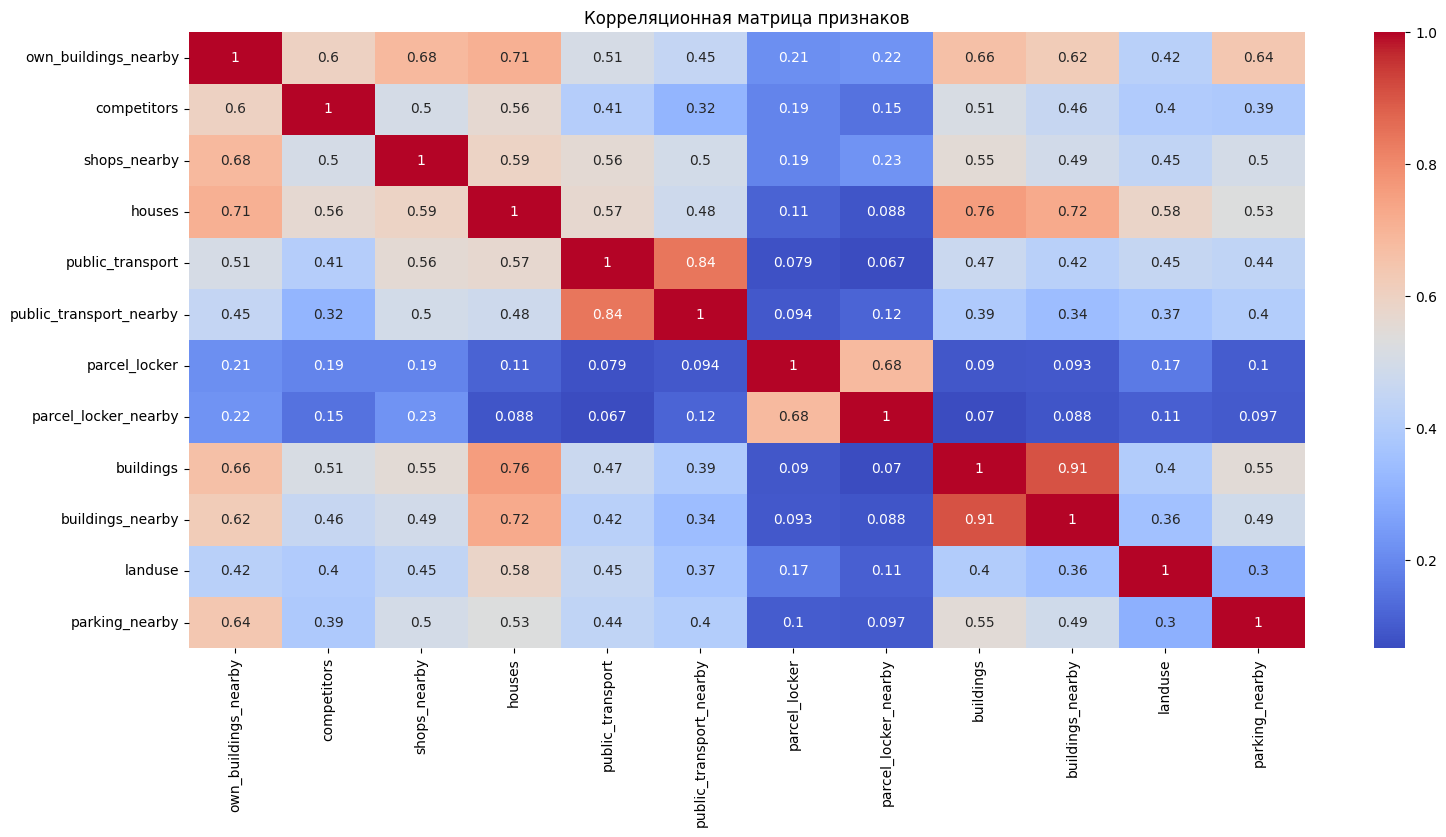

In [ ]:
corr_mat = main_gdf[features].corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

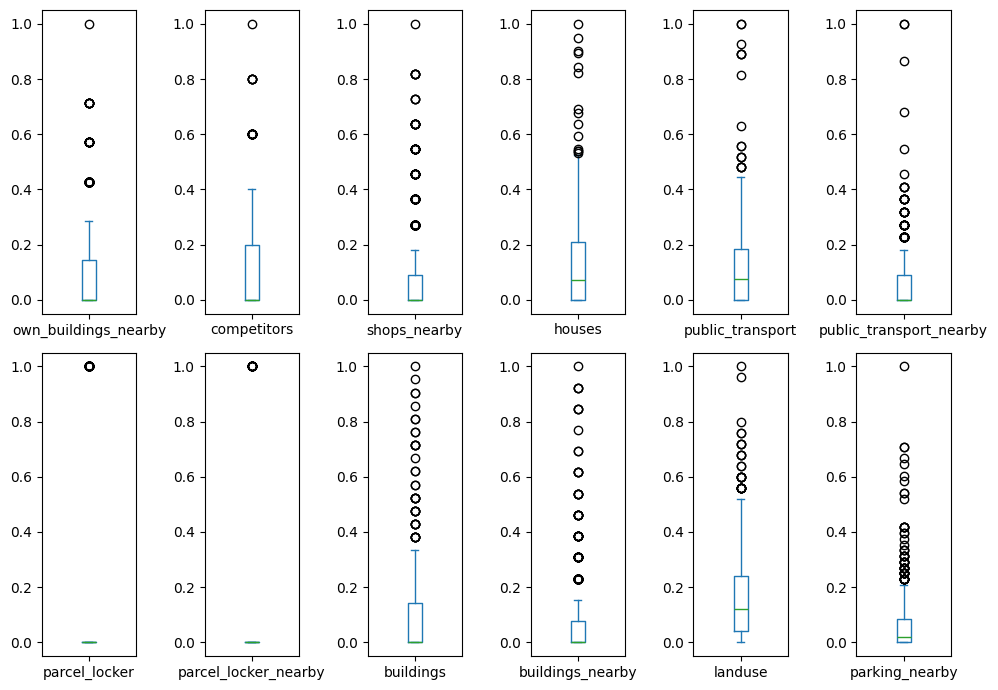

In [ ]:
main_gdf[features].plot(kind='box', subplots=True, layout=(2, 6), figsize=(10, 7))
plt.tight_layout()

Подобные выбросы ожидаемы, т.к. изучались участки как и с плотными жилыми районами, так и такие, что находятся в промышленных или малонаселенных участках. Пропусков в данных нет, поэтому, не будем никак обрабатывать данные

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)


Будем считать следующим образом:

Вычитать баллы будем за наличие поблизости уже существующих своих ПВЗ (наибольший штраф) и чуть меньше за наличие поблизости конкурентов

За остальное действуем следующим образом:

- в "двойных" признаках (которые учитываются и на 300, и на 600 м) будем считать больше баллов за ближайщие объекты, вычитывать эти объекты из числа тех, что находятся дальше, и назначать меньше за дальние объекты

- больше всего баллов будем назначать за наличие жилых домов, транспортных остановок и иных зданий (детсадов, офисов, школ и т.д.) поблизости. За остальные - меньше

In [10]:
# можно было бы и через матричное умножение, если бы я не сделал "двойные" признаки
main_gdf['index_score'] = (
    (main_gdf['own_buildings_nearby'] * -0.7) +
    (main_gdf['competitors'] * -0.15) +
    (main_gdf['shops_nearby']* 0.15) +
    (main_gdf['houses'] * 0.2) +
    ((main_gdf['public_transport']-main_gdf['public_transport_nearby'])* 0.03) +
    (main_gdf['public_transport_nearby'] * 0.1) +
    ((main_gdf['parcel_locker']-main_gdf['parcel_locker_nearby'])* 0.03) +
    (main_gdf['parcel_locker_nearby'] * 0.15) +
    ((main_gdf['buildings'] - main_gdf['buildings_nearby']) * 0.1) +
    (main_gdf['buildings_nearby'] * 0.22) +
    ((main_gdf['landuse']-main_gdf['houses']) * 0.05) +
    (main_gdf['parking_nearby'] * 0.15)
    )*10
main_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(main_gdf['index_score']))

   - Исследуйте распределение целевой переменной и оцените её сбалансированность

In [ ]:
main_gdf['index_score'].describe()

,index_score
count,802.000000
mean,0.618118
std,0.128903
min,0.000000
25%,0.595121
50%,0.630737
75%,0.674985
max,1.000000


<Axes: >

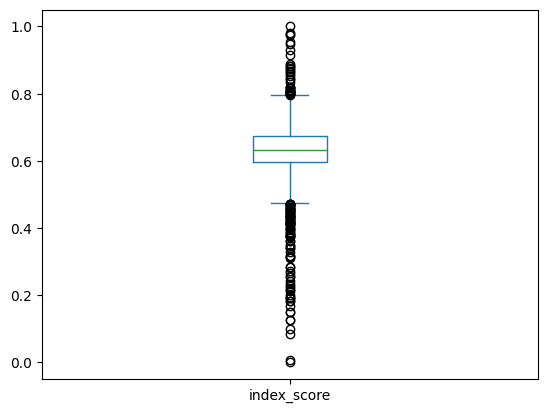

In [ ]:
main_gdf['index_score'].plot(kind='box')

In [ ]:
# Создаем карту
map_result = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=12, basemap='CartoDB.Positron')

# Добавляем H3 ячейки
map_result.add_data(
    main_gdf,
    column="index_score",
    cmap="OrRd",
    legend_title="index_score",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    }
)

# Отображаем карту
map_result

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

   - При необходимости, предложите стратегию работы с несбалансированными данными

Необходимости не вижу, как уже описывал ранее, подобные выбросы и возможная несбалансированность ожидаемы, так как работаем с различными районами города

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации

In [11]:
X = main_gdf[features].copy()
y = main_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=features)
X_df.index = main_gdf.index
y.index = main_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (802, 12)


,own_buildings_nearby,competitors,shops_nearby,houses,public_transport,public_transport_nearby,parcel_locker,parcel_locker_nearby,buildings,buildings_nearby,landuse,parking_nearby
0,0.000000,0.0,0.000000,0.000000,0.074074,0.000000,0.0,0.0,0.000000,0.000000,0.04,0.041667
1,0.000000,0.0,0.000000,0.000000,0.074074,0.045455,0.0,0.0,0.000000,0.000000,0.04,0.000000
2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00,0.000000
3,0.000000,0.0,0.000000,0.059211,0.148148,0.136364,0.0,0.0,0.047619,0.000000,0.12,0.020833
4,0.000000,0.0,0.000000,0.019737,0.074074,0.090909,0.0,0.0,0.000000,0.000000,0.36,0.020833
5,0.000000,0.2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.04,0.020833
6,0.714286,0.6,0.727273,0.394737,0.518519,0.409091,0.0,0.0,0.238095,0.153846,0.60,0.270833
7,0.000000,0.0,0.000000,0.032895,0.074074,0.090909,0.0,0.0,0.047619,0.000000,0.28,0.000000
8,0.000000,0.0,0.000000,0.000000,0.074074,0.000000,0.0,0.0,0.000000,0.000000,0.20,0.000000
9,0.000000,0.0,0.000000,0.394737,0.074074,0.045455,0.0,0.0,0.095238,0.153846,0.12,0.020833


In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

   - Проведите оценку важности признаков для каждой модели

<Axes: title={'center': 'Важности признаков'}>

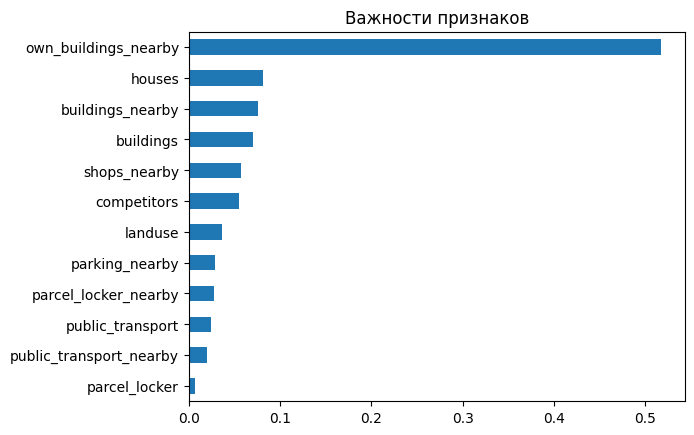

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

<Axes: title={'center': 'Важности признаков (без own_buildings_nearby)'}>

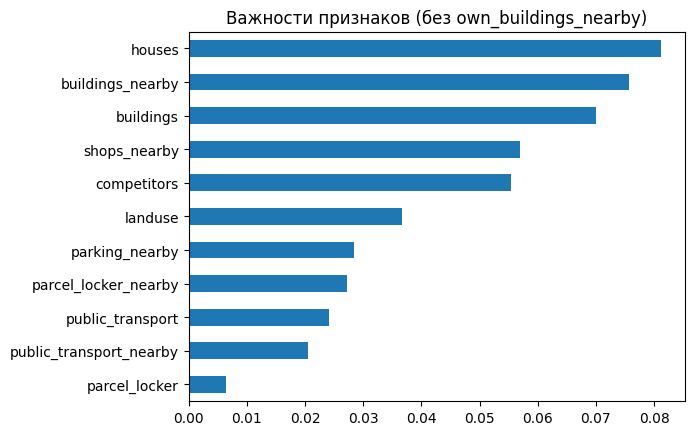

In [ ]:
feat2= ['competitors', 'shops_nearby', 'houses', 'public_transport',
        'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
        'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
feat_imp[feat2].sort_values().plot(kind='barh', title='Важности признаков (без own_buildings_nearby)')

   - Сравните модели по метрикам качества и выберите наилучшую

In [ ]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, y_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.894746,0.02118,0.0378
0,Random Forest,0.838365,0.02118,0.0378


   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

In [85]:
from sklearn.model_selection import GridSearchCV

n_estimators = [int(x) for x in range(50, 251, 10)]
learning_rate = np.arange(0.1, 2.0, 0.2)
max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)

param_grid = {
    'n_estimators': n_estimators
}

param2_grid = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)
rf_cv.fit(X_train, y_train)
gb_cv = GridSearchCV(estimator=gb, param_grid=param2_grid, cv=5, verbose=1, n_jobs=-1)
gb_cv.fit(X_train, y_train)

best_params_rf = rf_cv.best_params_
best_model_rf = rf_cv.best_estimator_
r2_best_rf = r2_score(y_test, best_model_rf.predict(X_test))

best_params_gb = gb_cv.best_params_
best_model_gb = gb_cv.best_estimator_
r2_best_gb = r2_score(y_test, best_model_gb.predict(X_test))

print(f"Лучшие параметры Random Forest: {best_params_rf}; R2: {r2_best_rf}")
print(f"Лучшие параметры Gradient Boosting: {best_params_gb}; R2: {r2_best_gb}")

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Fitting 5 folds for each of 1680 candidates, totalling 8400 fits
Лучшие параметры Random Forest: {'n_estimators': 240}; R2: 0.8638630479222048
Лучшие параметры Gradient Boosting: {'learning_rate': np.float64(0.5000000000000001), 'max_depth': 1, 'n_estimators': 250}; R2: 0.9823383198573319


3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам

Сначала определим оптимальное число k, далее применим KMeans++, DBSCAN/HDBSCAN, Agglomerative


   - Определите оптимальное число кластеров с помощью метода локтя или силуэта

In [13]:
%%capture
!pip install kneed

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


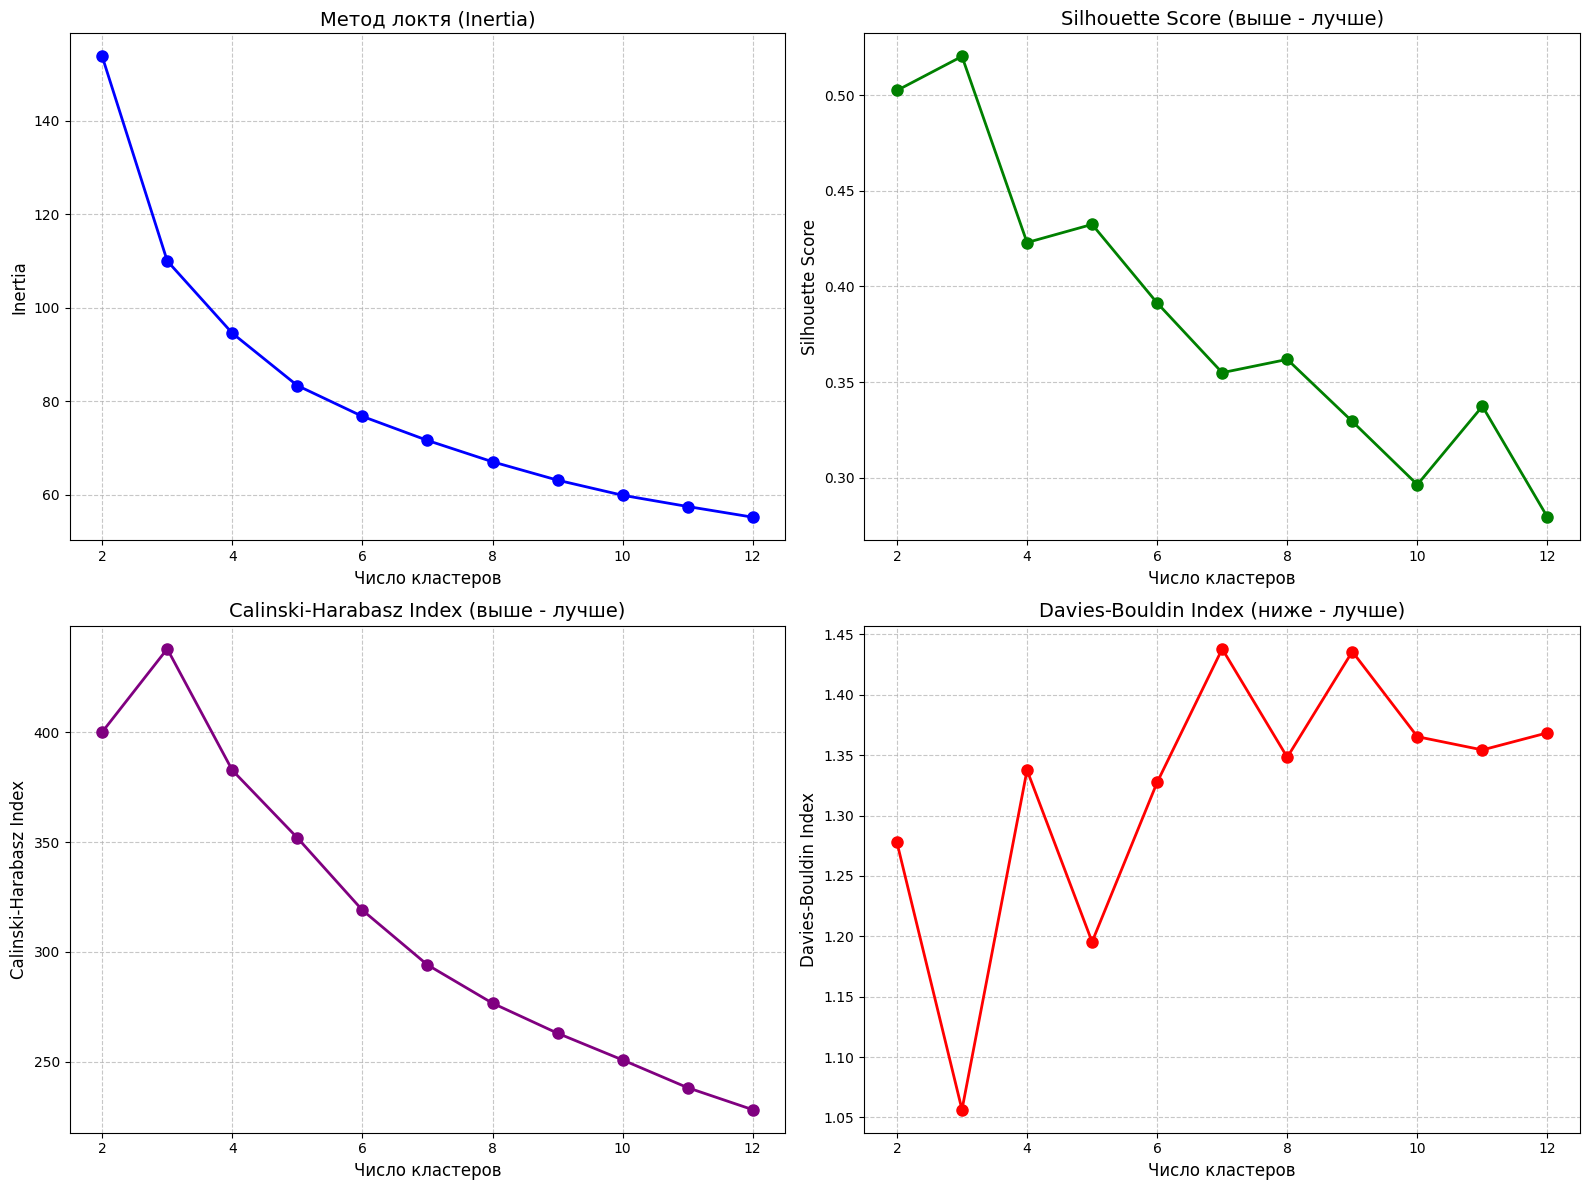


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 5
Silhouette Score: 3
Calinski-Harabasz Index: 3
Davies-Bouldin Index: 3

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,153.752210,0.502409,400.149733,1.277718
1,3,110.020751,0.520231,438.046626,1.056414
2,4,94.574358,0.422917,382.746530,1.337586
3,5,83.378152,0.432401,351.954657,1.195397
4,6,76.790157,0.391331,318.994219,1.327465
5,7,71.646613,0.354888,294.066779,1.438011
6,8,67.080194,0.361833,276.598690,1.348260
7,9,63.152566,0.329392,262.917049,1.435752
8,10,59.922361,0.296364,250.735387,1.365299
9,11,57.518113,0.337333,238.104010,1.354331


In [157]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=8):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

optimal_clusters = find_optimal_clusters(X_df, max_k=12)

In [137]:
optimal_clusters

{'inertia': np.int64(5),
 'silhouette': 3,
 'calinski': 3,
 'davies': 3,
 'metrics_df':     Число кластеров     Inertia  Silhouette Score  Calinski-Harabasz  \
 0                 2  166.207337          0.490747         374.275295   
 1                 3  122.015232          0.504933         399.290443   
 2                 4  106.514019          0.427995         343.263265   
 3                 5   95.223095          0.436930         311.238738   
 4                 6   87.165814          0.422250         286.381348   
 5                 7   80.512031          0.431928         268.999699   
 6                 8   74.117746          0.358703         259.936752   
 7                 9   70.203966          0.345610         245.345220   
 8                10   68.311592          0.263469         226.281193   
 9                11   63.984043          0.336619         222.502499   
 10               12   61.628424          0.298500         212.486147   
 
     Davies-Bouldin  
 0         1.

In [138]:
optimal_k = [i for i in range(optimal_clusters['silhouette'], optimal_clusters['silhouette']+3)]
optimal_k

[3, 4, 5]

   - Визуализируйте результаты кластеризации

In [173]:
from sklearn.decomposition import PCA
import plotly.express as px

# казалось более приятным визуализировать в 3д
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_df)

for k in optimal_k:
    kmeans_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_plus.fit_predict(X_df)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (KMeans++, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

In [174]:
from sklearn.cluster import AgglomerativeClustering


for k in optimal_k:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = pd.Series(hc.fit_predict(X_df).astype("str"), index=X_df.index)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (Agglomerative, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

In [175]:
import hdbscan


hdb = hdbscan.HDBSCAN(cluster_selection_epsilon=0.3)
labels = hdb.fit_predict(X_df).astype("str")
fig = px.scatter_3d(
    X_pca3,
    x=0,
    y=1,
    z=2,
    color=labels.astype("str"),
    title=f"Распределение ячеек по кластерам (HDBSCAN)",
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
)
fig.show()

In [176]:
hdb = hdbscan.HDBSCAN() #если просто запустить с eps=0, для сравнения
labels = hdb.fit_predict(X_df).astype("str")
fig = px.scatter_3d(
    X_pca3,
    x=0,
    y=1,
    z=2,
    color=labels.astype("str"),
    title=f"Распределение ячеек по кластерам (HDBSCAN)",
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
)
fig.show()

   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Будем использовать KMeans++ с K=5, т.к. подобное более детальное разделение кажется более привлекательным

In [162]:
kmeans_plus = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels = kmeans_plus.fit_predict(X_df)
X_clust_df = X_df.copy()
X_clust_df['cluster'] = labels

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust_df, y, test_size=0.4, random_state=42)

gbc = GradientBoostingRegressor(learning_rate=0.5, max_depth=1, n_estimators=250, random_state=42)
gbc.fit(Xc_train, yc_train)
gbc_pred = gbc.predict(Xc_test)

r2_gbc = r2_score(yc_test, gbc_pred)
mae_gbc = mean_absolute_error(yc_test, gbc_pred)
rmse_gbc = np.sqrt(mean_squared_error(yc_test, gbc_pred))
print(f'Gradient Boosting, R2: {r2_gbc}; MAE: {mae_gbc}; RMSE: {rmse_gbc}')

Gradient Boosting, R2: 0.982810047084208; MAE: 0.009786002355224067; RMSE: 0.016527408528782192


**Сравнение**:

- R2 с кластерами: 0.982810047084208
- R2 ранее: 0.9823383198573319

Кластеры улучшили результат, но очень незначительно (на ~0.0005)

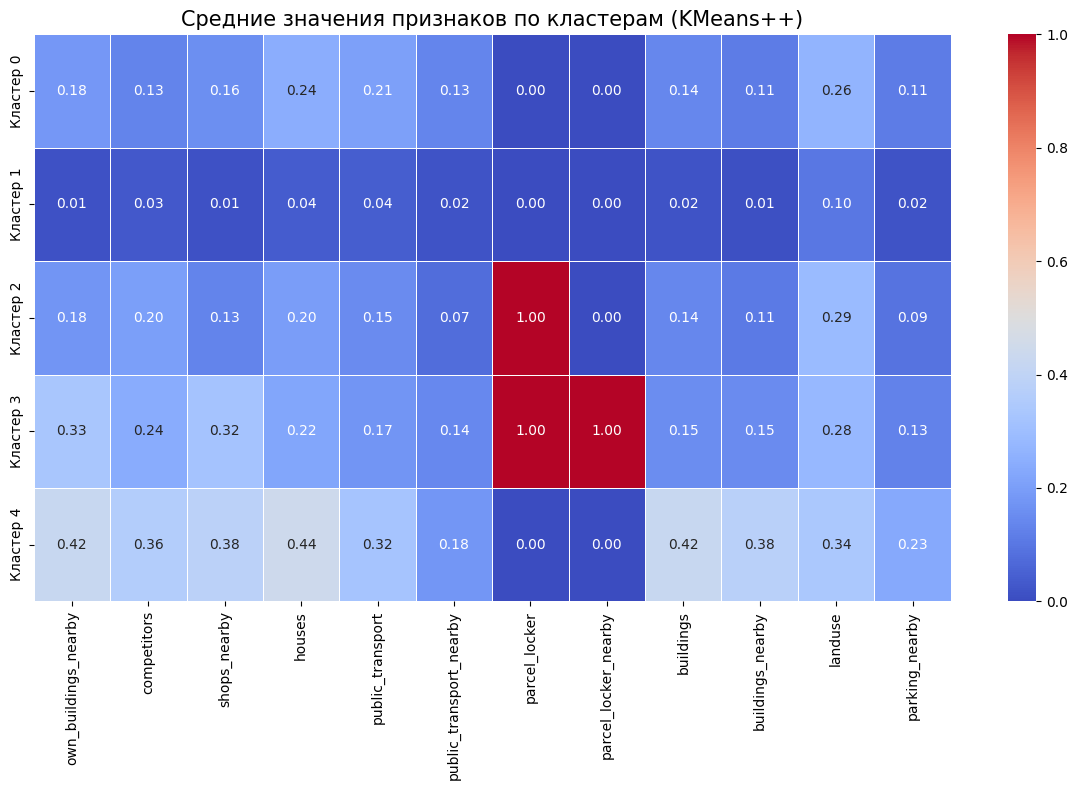

In [169]:
X_clust_df['index_score'] = y
X_clust_df.groupby('cluster')['index_score'].describe()

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

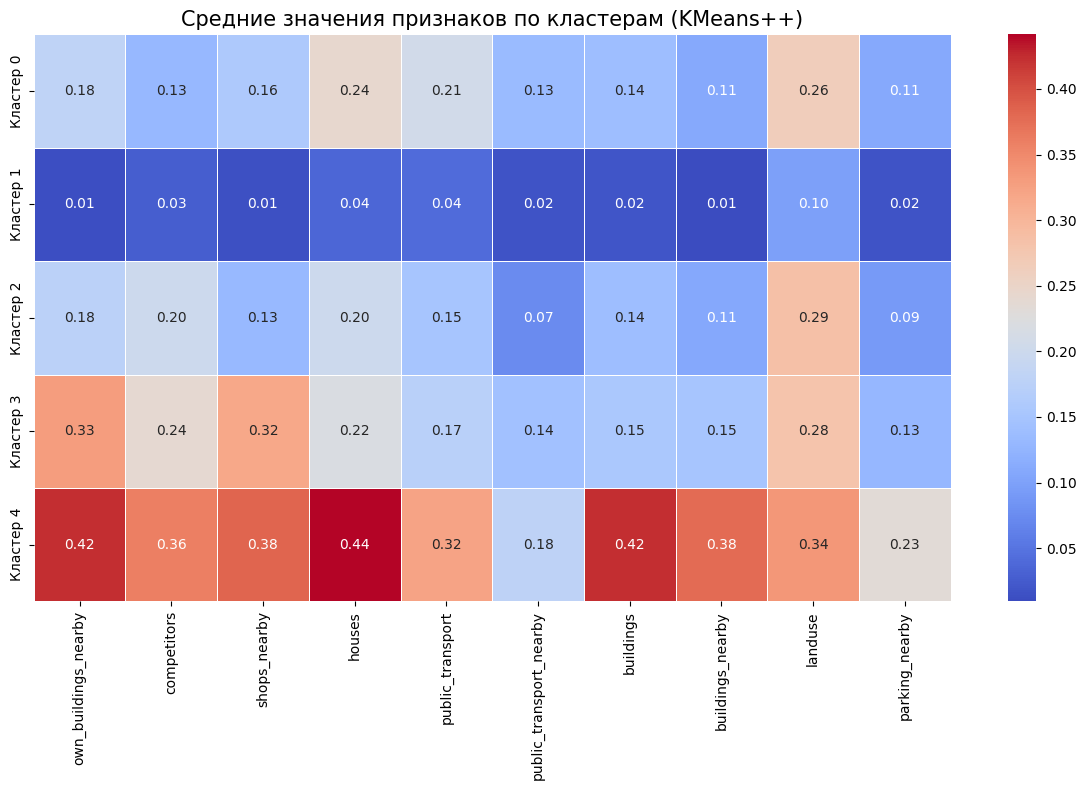

In [170]:
feat_no_pl= ['own_buildings_nearby', 'competitors', 'shops_nearby', 'houses',
             'public_transport', 'public_transport_nearby', 'buildings',
             'buildings_nearby', 'landuse', 'parking_nearby']
no_pl_df = X_clust_df.copy()
no_pl_df = no_pl_df[feat_no_pl]

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = no_pl_df[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=feat_no_pl
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции

уже сделано ранее

- Рассчитайте итоговый потенциал для всех ячеек сетки
- Категоризируйте потенциал для упрощения интерпретации результатов

Потенциал будем рассматривать следующим образом:

- 0.9-1.0 - самое рекомендуемое место (5)
- 0.8-0.9 - может подойти для открытия, на "втором плане" (4)
- 0.7-0.8 - есть возможности для открытия, но не особо рекомендуемые (3)
- 0.5-0.7 - в основном, нежилые места, или места, где недостаточно потенциала для открытия (2)
- 0.0-0.5 - места, в которых уже есть открытые ПВЗ, или высока конкурентность. не рекомендуется (1)

   - Обоснуйте выбранные веса в контексте вашего бизнеса

уже сделано ранее

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса

In [184]:
clust_gdf = main_gdf.copy()
clust_gdf['index_score'] = y
clust_gdf['cluster'] = X_clust_df['cluster'].astype(str)
bins = [0.0, 0.5, 0.7, 0.8, 0.9, 1.0]

labels = ['1', '2', '3', '4', '5']

clust_gdf['cat'] = pd.cut(
    clust_gdf['index_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

m4 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m4.add_data(
    clust_gdf,
    column="cat",
    cmap="OrRd",
    legend_title="cat",
    layer_name="H3 Сетка",
    scheme='EqualInterval',
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m4.add_gdf(ozon_gdf, layer_name='OZON Location', info_mode='on_click')
m4

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

   - Выделите топ-10 локаций с наивысшим потенциалом

In [185]:
best_gdf = clust_gdf.sort_values('index_score', ascending=False).head(10)
best_gdf

,h3_index,geometry,own_buildings_nearby,competitors,shops_nearby,houses,public_transport,public_transport_nearby,parcel_locker,parcel_locker_nearby,buildings,buildings_nearby,landuse,parking_nearby,index_score,cluster,cat
96,891181b061bffff,"POLYGON ((4176879.089 7443205.817, 4177143.052...",0.000000,0.0,0.090909,0.289474,0.259259,0.181818,0.0,0.0,0.523810,0.615385,0.16,0.041667,1.000000,0,5
794,891181b1617ffff,"POLYGON ((4177720.471 7432854.084, 4177984.095...",0.142857,0.4,0.727273,0.223684,0.185185,0.227273,1.0,1.0,0.095238,0.076923,0.24,0.145833,0.980502,3,5
623,891181b16cfffff,"POLYGON ((4177255.932 7431282.455, 4177519.507...",0.142857,0.4,0.545455,0.203947,0.407407,0.363636,1.0,1.0,0.095238,0.076923,0.56,0.125000,0.978525,3,5
624,891181b0663ffff,"POLYGON ((4178583.605 7443030.213, 4178847.552...",0.285714,0.4,0.272727,1.000000,0.296296,0.045455,0.0,0.0,0.904762,1.000000,0.56,0.145833,0.974625,4,5
480,891181b2acbffff,"POLYGON ((4179448.955 7453218.981, 4179713.228...",0.142857,0.2,0.000000,0.250000,0.148148,0.090909,1.0,1.0,0.285714,0.461538,0.16,0.208333,0.954238,3,5
544,891181b00c7ffff,"POLYGON ((4178722.644 7446800.992, 4178986.713...",0.142857,0.4,0.181818,0.328947,0.148148,0.045455,1.0,1.0,0.238095,0.307692,0.60,0.145833,0.946189,3,5
477,891181b312bffff,"POLYGON ((4174726.968 7444508.12, 4174990.985 ...",0.000000,0.2,0.454545,0.348684,0.259259,0.136364,0.0,0.0,0.190476,0.153846,0.28,0.125000,0.931039,0,5
147,891181b0603ffff,"POLYGON ((4177223.509 7443710.963, 4177487.486...",0.000000,0.4,0.181818,0.289474,0.296296,0.090909,0.0,0.0,0.476190,0.538462,0.12,0.166667,0.915708,4,5
214,891181b0673ffff,"POLYGON ((4178015.416 7443088.792, 4178279.369...",0.285714,0.4,0.090909,0.894737,0.296296,0.318182,0.0,0.0,0.904762,0.923077,0.40,0.083333,0.887369,4,4
527,891181b0073ffff,"POLYGON ((4180428.109 7446625.127, 4180692.162...",0.000000,0.4,0.181818,0.407895,0.148148,0.090909,0.0,0.0,0.285714,0.230769,0.76,0.104167,0.881158,0,4


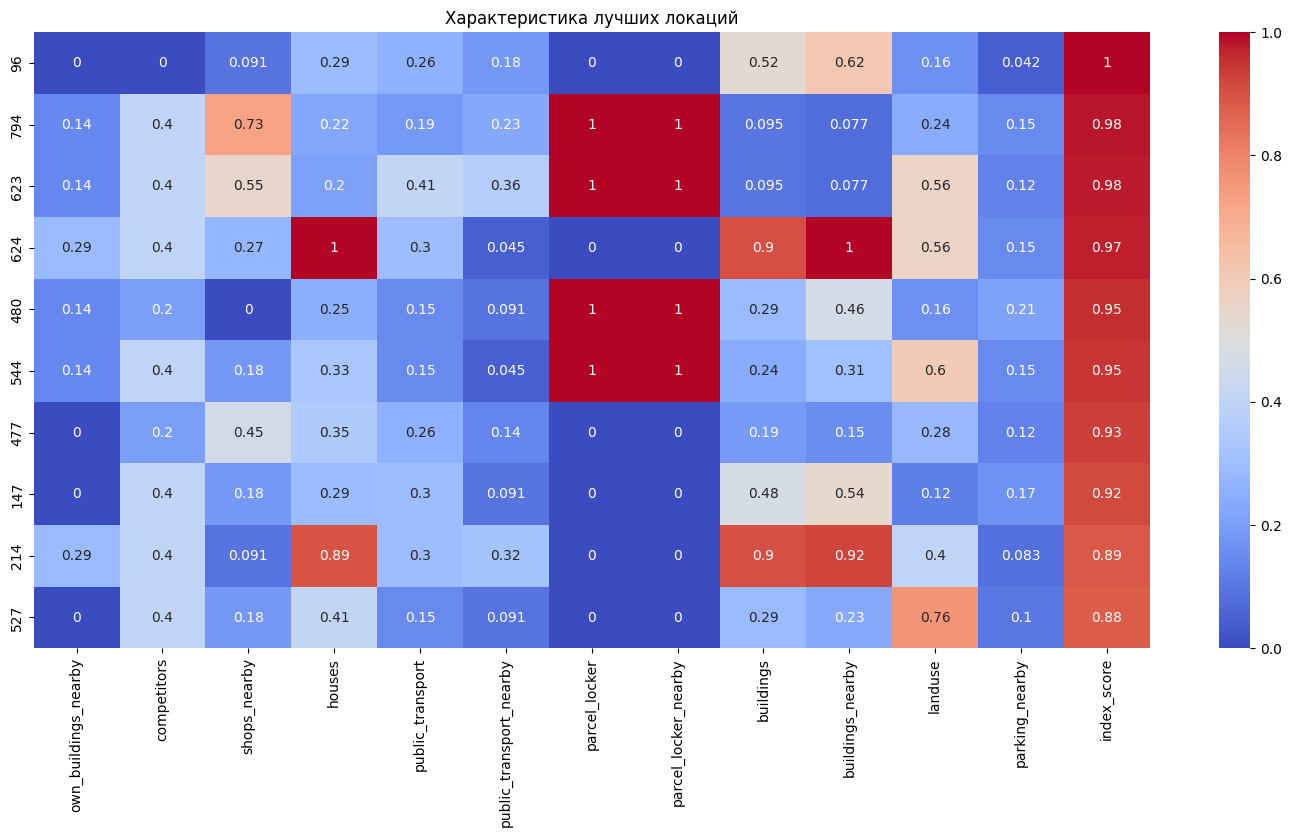

In [211]:
fin_feat = features.copy()
fin_feat.append('index_score')

plt.figure(figsize=(18, 8))
sns.heatmap(best_gdf[fin_feat], annot=True, cmap='coolwarm')
plt.title('Характеристика лучших локаций')
plt.show()

   - Подготовьте отдельную карту фокуса на лучших локациях

In [200]:
m5 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

data = []
for h3_id in best_gdf['h3_index']:
    lat, lng = h3.h3_to_geo(h3_id)
    data.append({'h3_id': h3_id, 'lat': lat, 'lng': lng})

df_centers = pd.DataFrame(data)
gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"  # WGS 84 coordinate system
)

m5.add_gdf(
    gdf_centers,
    layer_name="best points",
    info_mode='on_click'
)

m5.add_data(
    best_gdf,
    column='index_score',
    cmap="Greens",
    k=11,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m5

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

3. **Формирование бизнес-рекомендаций**:
    - Составьте список из 5-7 конкретных локаций для размещения новых объектов
    - Для каждой рекомендуемой локации укажите:
      * Точные координаты
      * Значение потенциала
      * Ключевые характеристики локации
      * Преимущества и возможные риски размещения в данной точке

Адрес и координаты будут выбираться примерно близкими к выбранным ячейкам

|Номер|Коорд-ты|Адрес|Index Score|Хар-ки|Преимущества и риски|
|-|-|-|-|-|-|
|1|55.417848, 37.520806|Подольск, Высотная улица, 7|1.0|Наличие поблизости наибольшего кол-ва<br> спорт. центров, офисных зданий, дет. садов;<br>Вблизи достаточно жилых домов;<br>Расположение вблизи крупной автодороги|**Плюсы**: Много людей днём (офисы + спорт),<br> хорошая видимость с трассы, семьи с детьми рядом<br><br>**Риски**: Пробки на дороге, может быть сложно с парковкой,<br> возможна высокая аренда|
|2|55.364118, 37.533149|Подольск, мкр. Климовск, Первомайская улица, 10|0.98|Поблизости крупные жилые районы;<br>Нахождение в условной близости к автомагистрали;<br>Отмечено, что поблизости есть постамат;<br>В среднем радиусе находится рынок и пром.зона|**Плюсы**: Много потенциальных клиентов из жилых домов,<br> удобно для доставки с трассы, постамат подтверждает спрос<br><br>**Риски**: Промзона может отпугивать часть клиентов,<br> возможен шум от дороги|
|3|55.357695, 37.527516|Подольск, микрорайон Климовск, Вокзальная улица, 2|0.978|Прямая близость с ж/д станцией и автобусными станциями Гривно;<br>Наличие парковки и постамата;<br>Достаточное кол-во магазинов поблизости|**Плюсы**: Отличная доступность на транспорте,<br> высокий поток пассажиров, удобно забирать по пути<br><br>**Риски**: Может быть людно и шумно,<br> аренда рядом с вокзалом часто дороже|
|4|55.417807, 37.541216|Подольск, Народная улица, 13А|0.975|Само здание еще недостроено;<br>Поблизости много жилых домов;<br>Расположение внутри жилого комплекса;<br>Рядом есть автобусная остановка;<br>Вблизи расположены дет.сады, школы и другие магазины|**Плюсы**: Новые жители = новые клиенты, «своя» аудитория внутри ЖК<br><br>**Риски**: Строительство может задержаться, пока мало видимости с улицы,<br> зависимость от заселения ЖК|
|5|55.469362, 37.546426|Подольск, Тепличная улица, 12|0.954|Наличие постамата;<br>Прямой доступ к общественному транспорту;<br>Нахождение вблизи многоэтажных жилых домов;<br>Наличие наибольшего числа парковок поблизости;<br>Наличие в ближайшем радиусе школ, их отделений и дет.садов|**Плюсы**: Лучшая парковка из всех точек, много семей с детьми,<br> удобно заезжать на машине<br><br>**Риски**: Рядом уже есть постамат - часть клиентов уже обслуживается,<br> возможна конкуренция за трафик|

In [217]:
m6 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

coords = np.array([
    [55.417848, 37.520806],
    [55.364118, 37.533149],
    [55.357695, 37.527516],
    [55.417807, 37.541216],
    [55.469362, 37.546426]
])

points_gdf = gpd.GeoDataFrame(
    {'lat': coords[:, 0], 'lon': coords[:, 1]},
    geometry=gpd.points_from_xy(coords[:, 1], coords[:, 0]),
    crs="EPSG:4326"
)

m6.add_gdf(
    points_gdf,
    layer_name="best points",
    info_mode='on_click'
)

m6.add_data(
    best_gdf.head(5),
    column='index_score',
    cmap="Greens",
    k=6,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m6

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

1. Необходимо открываться рядом с жилыми домами, в густонаселённых районах.
2. Избегать прямой конкуренции, не открывать новый пункт рядом с уже работающими ПВЗ (своими или конкурентов).
3. Необходимо учитывать трафик - открываться рядом с остановками, магазинами, школами, ведь так людям удобнее заходить по пути.
4. Учитывать парковку, ведь она является плюсом для клиентов с крупными заказами.
5. Лучше начинать с малого, сначала покрывать районы, где вообще нет ПВЗ, потом уже переходить на более крупные.

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.